Part A

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import os

In [ ]:
data = pd.read_csv('https://webpages.charlotte.edu/mschuck1/classes/DTSC2301/Data/adult-census-numeric-all.csv')
print(data.head())

   age  education-num  capital-gain  capital-loss  hours-per-week   class
0   25              7             0             0              40   <=50K
1   38              9             0             0              50   <=50K
2   28             12             0             0              40    >50K
3   44             10          7688             0              40    >50K
4   18             10             0             0              30   <=50K


In [ ]:
features = ['age','education-num','capital-gain','capital-loss','hours-per-week']
X = data[features]
y = data['class']
over50k = data['class'][2]
y = (y == over50k).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear Kernel)": SVC(kernel='linear'),
    "SVM (RBF Kernel)": SVC(kernel='rbf'),
    "LDA": LinearDiscriminantAnalysis(),
    "Decision Tree (Depth=3)": DecisionTreeClassifier(max_depth=3),
    "Decision Tree (Depth=5)": DecisionTreeClassifier(max_depth=5),
    "Decision Tree (Depth=7)": DecisionTreeClassifier(max_depth=7),
    "Decision Tree (Depth=8)": DecisionTreeClassifier(max_depth=8),
    "Decision Tree (Depth=9)": DecisionTreeClassifier(max_depth=9)
}
models2 = {
    "Decision Tree (Depth=10)": DecisionTreeClassifier(max_depth=10)
}

results = {}

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

for model_name, model in models2.items():
    scores = cross_val_score(model, X_scaled, y, cv=4, scoring='accuracy')
    results[model_name] = np.mean(scores)

print(results)

{'Decision Tree (Depth=10)': np.float64(0.8360837820198234)}


In [ ]:
import itertools

dict = {}

def train_model_with_features(features):
    """
    Placeholder function to train a model with the given features.
    Replace this with your actual model training code.
    """
    print(f"Training model with features: {features}")
    scores = cross_val_score(DecisionTreeClassifier(max_depth=9), X_scaled, y, cv=8, scoring='accuracy')
    print(np.mean(scores))
    comma_separated_string = ", ".join(features)
    dict[comma_separated_string] = np.mean(scores)

def loop_feature_variations(feature_list):
    """
    Loops through all possible combinations of features from the given list,
    and trains a model for each combination.
    """
    for r in range(1, len(feature_list) + 1):
        for subset in itertools.combinations(feature_list, r):
            train_model_with_features(list(subset))

loop_feature_variations(features)

max_key = max(dict, key=dict.get)
max_value = dict[max_key]

print(f"Best Accuracy: {max_key}-{max_value}")

Training model with features: ['age']
0.836738930142959
Training model with features: ['education-num']
0.8367389234364341
Training model with features: ['capital-gain']
0.8369027202469719
Training model with features: ['capital-loss']
0.8368412918322843
Training model with features: ['hours-per-week']
0.8368617702060217
Training model with features: ['age', 'education-num']
0.836923188560922
Training model with features: ['age', 'capital-gain']
0.8367184450626965
Training model with features: ['age', 'capital-loss']
0.8367798667708592
Training model with features: ['age', 'hours-per-week']
0.8368822385199719
Training model with features: ['education-num', 'capital-gain']
0.8368208101052843
Training model with features: ['education-num', 'capital-loss']
0.8368003417913343
Training model with features: ['education-num', 'hours-per-week']
0.8368822418732343
Training model with features: ['capital-gain', 'capital-loss']
0.8367593917503842
Training model with features: ['capital-gain', 'ho

Part B

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

import statsmodels.api as sm
def specificity_score(y_true, y_pred):
    """
    Calculate specificity.

    Args:
        y_true (list or numpy.ndarray): True labels.
        y_pred (list or numpy.ndarray): Predicted labels.

    Returns:
        float: Specificity score.
    """
    true_negatives = sum((y_true == 0) & (y_pred == 0))
    false_positives = sum((y_true == 0) & (y_pred == 1))

    if (true_negatives + false_positives) == 0:
      return 0.0

    specificity = true_negatives / (true_negatives + false_positives)
    return specificity
overdrawn = pd.read_csv("https://webpages.charlotte.edu/mschuck1/classes/DTSC2301/Data/credit_card_defaults.csv")
overdrawn.dropna(inplace=True)
overdrawn.info()

print(overdrawn.columns)

overdrawn_X = overdrawn[['SEX','EDUCATION','MARRIAGE']]
overdrawn_X = sm.add_constant(overdrawn_X)
overdrawn_y = overdrawn['default payment next month']
model2_sm = sm.Logit(overdrawn_y, overdrawn_X).fit()
print(model2_sm.summary())

# Define y_true and y_pred before calculating accuracy
y_true = overdrawn_y
y_pred = (model2_sm.predict(overdrawn_X) > 0.5).astype(int) # Convert predictions to 0/1

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

Part C

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

data = pd.read_csv("https://webpages.charlotte.edu/mschuck1/classes/DTSC2301/Data/orings_long.csv")
data.dropna(inplace=True)
data.info()

data['Damaged_Numeric'] = (data['Damaged'] > 0).astype(int)

X = data['Temp']
y = data['Damaged_Numeric']

X = sm.add_constant(X)

modelr_sm = sm.Logit(y, X).fit()

print(modelr_sm.summary())

temperatures = [30, 40, 50]
X_temps = sm.add_constant(pd.DataFrame({'Temp': temperatures}))
predicted_probs = modelr_sm.predict(X_temps)
print(predicted_probs)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    138 non-null    int64
 1   Damaged       138 non-null    int64
 2   Temp          138 non-null    int64
 3   Pressure.psi  138 non-null    int64
 4   Order         138 non-null    int64
dtypes: int64(5)
memory usage: 5.5 KB
Optimization terminated successfully.
         Current function value: 0.218827
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        Damaged_Numeric   No. Observations:                  138
Model:                          Logit   Df Residuals:                      136
Method:                           MLE   Df Model:                            1
Date:                Sun, 06 Apr 2025   Pseudo R-squ.:                 0.09234
Time:                        14:52:19   Log-Likelihood:                -30

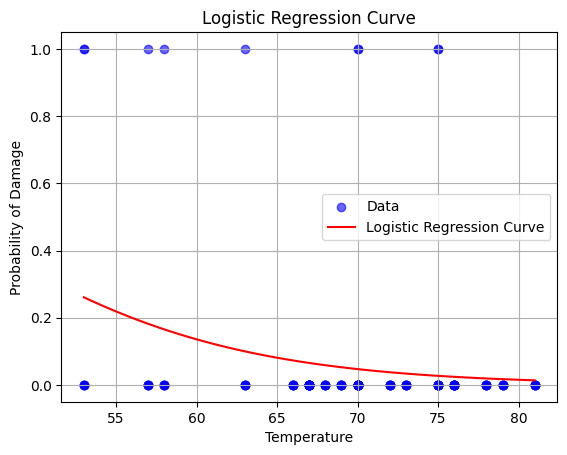

In [ ]:
import matplotlib.pyplot as plt

temp_range = np.linspace(data['Temp'].min(), data['Temp'].max(), 100)
X_curve = sm.add_constant(pd.DataFrame({'Temp': temp_range}))

predicted_curve = modelr_sm.predict(X_curve)

plt.scatter(data['Temp'], data['Damaged_Numeric'], label='Data', color='blue', alpha=0.6)

plt.plot(temp_range, predicted_curve, label='Logistic Regression Curve', color='red')

plt.xlabel('Temperature')
plt.ylabel('Probability of Damage')
plt.title('Logistic Regression Curve')
plt.legend()
plt.grid(True)

plt.show()